In [206]:
%%html
<style>
/* ── Reveal.js: paginate long slides instead of scrolling ──────────────
   Each slide scrolls internally within the viewport — no content cut off.
   Works by enabling Reveal.js scroll layout for the whole deck.
──────────────────────────────────────────────────────────────────────── */

/* Give every slide its own scrollable page */
.reveal .slides section {
    display: block !important;
    height: 100vh !important;
    max-height: 100vh !important;
    overflow-y: auto !important;
    overflow-x: hidden !important;
    box-sizing: border-box !important;
    font-size: 0.80em !important;
    padding: 0.5em 1em !important;
    scroll-behavior: smooth;
}

/* Code cells */
.reveal .slides section pre,
.reveal .slides section code {
    font-size: 0.70em !important;
    max-height: none !important;   /* let the slide scroll handle it */
    overflow: visible !important;
    box-sizing: border-box !important;
    white-space: pre-wrap !important;
    word-break: break-word !important;
}

/* Tables */
.reveal .slides section table {
    font-size: 0.76em !important;
    width: 100% !important;
    table-layout: fixed !important;
    word-wrap: break-word !important;
}

/* Images */
.reveal .slides section img {
    max-width: 90% !important;
    max-height: 55vh !important;
    width: auto !important;
    display: block !important;
    margin: 0 auto !important;
}

/* Output areas */
.reveal .slides section .output_area,
.reveal .slides section .jp-OutputArea {
    max-height: none !important;
    overflow: visible !important;
    font-size: 0.80em !important;
}
</style>
<script>
// After Reveal.js is initialised, enable per-slide scrolling
(function waitForReveal() {
  if (typeof Reveal !== 'undefined' && Reveal.isReady && Reveal.isReady()) {
    Reveal.configure({
      scrollLayout: 'full',   // modern Reveal.js 4.x
      mouseWheel: false,       // keep arrow-key nav
      touch: true
    });
  } else {
    setTimeout(waitForReveal, 200);
  }
})();
</script>

# Hyperparameter Optimization Example

This Jupyter Notebook is made for illustrating, through a mixture of slides and code in an interactive fashion, several different methods for optimising Hyperparameters for Machine Learning models.  First it shows the most naive, manual approach, then grid search, and finally Bayesian optimization. 

- Last updated 2026-09-17 

***

This notebook uses the __[HTRU2 Pulsar dataset](https://archive.ics.uci.edu/ml/datasets/HTRU2)__ dataset as example data for Hyperparameter Optimization (HPO).

The focus on this small example is neither the actual code nor getting any specific results, but - hopefully - getting a better understanding of HPO. This is also why we don't describe the code in great detail - and simply load the dataset from a csv file directly - but the first part of the code should hopefully look familiar.

1. Naive, manual approach
2. Grid search
3. Random search
4. Bayesian optimization
5. "Full" scan over parameter space
6. New methods (BOHB, **Hyperuniform Sampling**)
7. Modern landscape (PBT, LLM-guided, NAS, LLM fine-tuning HPO)
8. New software


- __[HTRU2 Pulsar dataset](https://archive.ics.uci.edu/ml/datasets/HTRU2)__

- Focus on the understanding of hyperparameter optimization, not the actual code nor the data!

***

### Nomenclature (i.e. naming scheme)
- Machine Learning Model: $\mathcal{A}$
- $N$ hyperparameters
- Domain: $\Lambda_n$
- Hyperparameter configuration space: $\mathbf{\Lambda}=\Lambda_1 \times \Lambda_2 \times \dots \times \Lambda_N $
- Vector of hyperparameters: $\mathbf{\lambda} \in \mathbf{\Lambda}$
- Specific ML model: $\mathcal{A}_\mathbf{\lambda}$

### Domain of hyperparameters:

1. real
2. integer
3. binary
4. categorical

### Goal:

Given a dataset $\mathcal{D}$, find the vector of HyperParameters $\mathbf{\lambda}^{*}$, which performs "best", i.e. minimizes the expected loss function $\mathcal{L}$ for the model $\mathcal{A}_\mathbf{\lambda}$ on the test set of the data $D_\mathrm{test}$:

$$ \mathbf{\lambda}^{*} = \mathop{\mathrm{argmin}}_{\mathbf{\lambda} \in \mathbf{\Lambda}} \mathbb{E}_{D_\mathrm{test} \thicksim \mathcal{D}} \, \left[ \mathbf{V}\left(\mathcal{L}, \mathcal{A}_\mathbf{\lambda}, D_\mathrm{test}\right) \right]  $$

In practice we have to approximate the expectation above. 

***

First, we import the modules we want to use:

### Important
Make sure that you have some additional packages installed:

pip install graphviz 

conda install -c conda-forge bayesian-optimization

conda install -c conda-forge optuna

pip install optuna-integration




In [207]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from sklearn.datasets import load_iris, load_wine
from sklearn.metrics import accuracy_score
from IPython.display import SVG
from graphviz import Source
from IPython.display import display                               
from ipywidgets import interactive
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, poisson

import warnings
# warnings.filterwarnings('ignore')

We read in the data:

In [208]:
df = pd.read_csv('./data/Pulsar_data.csv')

df.head(10)

,Mean_SNR,STD_SNR,Kurtosis_SNR,Skewness_SNR,Class
0,27.555184,61.719016,2.208808,3.662680,1
1,1.358696,13.079034,13.312141,212.597029,1
2,73.112876,62.070220,1.268206,1.082920,1
3,146.568562,82.394624,-0.274902,-1.121848,1
4,6.071070,29.760400,5.318767,28.698048,1
5,32.919732,65.094197,1.605538,0.871364,1
6,34.101171,62.577395,1.890020,2.572133,1
7,50.107860,66.321825,1.456423,1.335182,1
8,176.119565,59.737720,-1.785377,2.940913,1
9,183.622910,79.932815,-1.326647,0.346712,1


We then divide the dataset in input features (X) and target (y):

In [209]:
X = df.drop(columns='Class')
y = df['Class']
feature_names = df.columns.tolist()[:-1]

print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.20, 
                                                    random_state=42)
X_train.head(10)

(3278, 4)


,Mean_SNR,STD_SNR,Kurtosis_SNR,Skewness_SNR
233,159.849498,76.740010,-0.575016,-0.941293
831,4.243311,26.746490,7.110978,52.701218
2658,1.015050,10.449662,15.593479,316.011541
2495,2.235786,19.071848,9.659137,99.294390
2603,2.266722,15.512103,9.062942,99.652157
111,121.404682,47.965569,0.663053,1.203139
1370,35.209866,60.573157,1.635995,1.609377
1124,199.577759,58.656643,-1.862320,2.391870
2170,0.663043,8.571517,23.415092,655.614875
2177,3.112876,16.855717,8.301954,90.378150


And check out the y values (which turns out to be balanced):

In [210]:
y_train.head(10)

233     1
831     1
2658    0
2495    0
2603    0
111     1
1370    1
1124    1
2170    0
2177    0
Name: Class, dtype: int64

In [211]:
y_train.value_counts()

Class
0    1319
1    1303
Name: count, dtype: int64

***

## Part A: Naïve Approach

- Manual configuration
- _"[Babysitting is also known as Trial & Error or Grad Student Descent in the academic field](https://blog.floydhub.com/guide-to-hyperparameters-search-for-deep-learning-models/)"_

In [212]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

def fit_and_graph_estimator(estimator):
    # fit the model
    estimator.fit(X_train, y_train)

    # training accuracy
    accuracy = accuracy_score(y_train, estimator.predict(X_train))
    print(f"Training Accuracy: {accuracy:.4f}")

    # plot the tree directly with matplotlib
    plt.figure(figsize=(14, 8))
    plot_tree(estimator, 
              feature_names=feature_names, 
              class_names=[str(i) for i in range(y_train.nunique())],
              filled=True,
              rounded=True,
              fontsize=10)
    plt.show()

    return estimator


def plot_tree_wrapper(max_depth=1, min_samples_leaf=1):
    estimator = DecisionTreeClassifier(
        random_state=42,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf
    )
    return fit_and_graph_estimator(estimator)


# keep interactive if widgets work
try:
    from ipywidgets import interactive
    from IPython.display import display

    display(interactive(plot_tree_wrapper, 
                        max_depth=(1, 10, 1), 
                        min_samples_leaf=(1, 100, 1)))
except Exception as e:
    print("⚠️ ipywidgets not available, falling back to static plot.")
    print(f"(Error was: {e})\n")
    plot_tree_wrapper(max_depth=3, min_samples_leaf=5)

# Graphviz Version below
"""def fit_and_graph_estimator(estimator):
    
    estimator.fit(X_train, y_train)
    
    accuracy = accuracy_score(y_train, estimator.predict(X_train))
    print(f'Training Accuracy: {accuracy:.4f}')
    
    class_names = [str(i) for i in range(y_train.nunique())]
    graph = Source(tree.export_graphviz(estimator, 
                                        out_file=None, 
                                        feature_names=feature_names, 
                                        class_names=class_names, 
                                        filled = True))
    display(SVG(graph.pipe(format='svg')))
    return estimator


def plot_tree(max_depth=1, min_samples_leaf=1):
    
    estimator = DecisionTreeClassifier(random_state=42, 
                                       max_depth=max_depth, 
                                       min_samples_leaf=min_samples_leaf)
    
    return fit_and_graph_estimator(estimator)

display(interactive(plot_tree, 
                    max_depth=(1, 10, 1), 
                    min_samples_leaf=(1, 100, 1)))"""

interactive(children=(IntSlider(value=1, description='max_depth', max=10, min=1), IntSlider(value=1, descripti…

"def fit_and_graph_estimator(estimator):\n    \n    estimator.fit(X_train, y_train)\n    \n    accuracy = accuracy_score(y_train, estimator.predict(X_train))\n    print(f'Training Accuracy: {accuracy:.4f}')\n    \n    class_names = [str(i) for i in range(y_train.nunique())]\n    graph = Source(tree.export_graphviz(estimator, \n                                        out_file=None, \n                                        feature_names=feature_names, \n                                        class_names=class_names, \n                                        filled = True))\n    display(SVG(graph.pipe(format='svg')))\n    return estimator\n\n\ndef plot_tree(max_depth=1, min_samples_leaf=1):\n    \n    estimator = DecisionTreeClassifier(random_state=42, \n                                       max_depth=max_depth, \n                                       min_samples_leaf=min_samples_leaf)\n    \n    return fit_and_graph_estimator(estimator)\n\ndisplay(interactive(plot_tree, \n           

__(Test this interactively in notebook)__

And test this configuration out on the test data:

In [213]:
clf_manual = DecisionTreeClassifier(random_state=42, 
                                    max_depth=10, 
                                    min_samples_leaf=5)

clf_manual.fit(X_train, y_train)
accuracy_manual = accuracy_score(y_test, clf_manual.predict(X_test))
print(f'Accuracy Manual: {accuracy_manual:.4f}')

Accuracy Manual: 0.8201


## Part B: Grid Search

Grid Search: 

- _full factorial design_ 
- Cartesian product
- Curse of dimensionality (grows exponentially)


![Grid Search](./images/GridSearch.png)

***

__[Grid Search](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV
)__ with Scikit Learn:

In [214]:
parameters_GridSearch = {'max_depth':[1, 50, 100], 
                         'min_samples_leaf':[1, 50, 100],
                        }

In [215]:
clf_DecisionTree = DecisionTreeClassifier(random_state=42)

In [216]:
GridSearch = GridSearchCV(clf_DecisionTree, 
                          parameters_GridSearch, 
                          cv=5, 
                          return_train_score=True, 
                          refit=True, 
                         )

In [217]:
GridSearch.fit(X_train, y_train);

In [218]:
GridSearch_results = pd.DataFrame(GridSearch.cv_results_)        

In [219]:
print("Grid Search: \tBest parameters: ", GridSearch.best_params_, f", Best scores: {GridSearch.best_score_:.4f}\n")

Grid Search: 	Best parameters:  {'max_depth': 1, 'min_samples_leaf': 1} , Best scores: 0.8551



In [220]:
GridSearch_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.005311,0.002695,0.001192,0.000734,1,1,"{'max_depth': 1, 'min_samples_leaf': 1}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
1,0.004947,0.005077,0.001248,0.001093,1,50,"{'max_depth': 1, 'min_samples_leaf': 50}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
2,0.004688,0.002444,0.002454,0.002077,1,100,"{'max_depth': 1, 'min_samples_leaf': 100}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
3,0.016639,0.003296,0.001808,0.001492,50,1,"{'max_depth': 50, 'min_samples_leaf': 1}",0.826667,0.796190,0.841603,...,0.824190,0.015056,8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,0.005683,0.003353,0.001155,0.002310,50,50,"{'max_depth': 50, 'min_samples_leaf': 50}",0.853333,0.834286,0.862595,...,0.849356,0.014683,6,0.865045,0.862184,0.858913,0.861296,0.860343,0.861556,0.002054
5,0.009088,0.004498,0.001925,0.001655,50,100,"{'max_depth': 50, 'min_samples_leaf': 100}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
6,0.015479,0.003663,0.002363,0.001898,100,1,"{'max_depth': 100, 'min_samples_leaf': 1}",0.826667,0.796190,0.841603,...,0.824190,0.015056,8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
7,0.008652,0.002356,0.001122,0.001223,100,50,"{'max_depth': 100, 'min_samples_leaf': 50}",0.853333,0.834286,0.862595,...,0.849356,0.014683,6,0.865045,0.862184,0.858913,0.861296,0.860343,0.861556,0.002054
8,0.006815,0.002035,0.001649,0.001520,100,100,"{'max_depth': 100, 'min_samples_leaf': 100}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340


In [221]:
clf_GridSearch = GridSearch.best_estimator_

In [222]:
accuracy_GridSearch = accuracy_score(y_test, clf_GridSearch.predict(X_test))
print(f'Accuracy Manual:      {accuracy_manual:.4f}')
print(f'Accuracy Grid Search: {accuracy_GridSearch:.4f}')

Accuracy Manual:      0.8201
Accuracy Grid Search: 0.8430


***

## Part C: Random Search

- $B$ function evaluations, $N$ hyperparameters, $y$ number of different values:

$$ y_{\mathrm{Grid Search}} = B^{1/N}, \quad y_{\mathrm{Random Search}} = B  $$

<img src="images/RandomSearch.png" alt="Random Search" width="400"/>

- _"This failure of grid search is the rule rather than the exception in high dimensional
hyper-parameter optimization"_ [Bergstra, 2012]

- useful baseline because (almost) no assumptions about the ML algorithm being optimized.

***

__[Random Search](http://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf)__ with __[Scikit Learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#sklearn.model_selection.RandomizedSearchCV)__ using __[Scipy Stats](https://docs.scipy.org/doc/scipy/reference/stats.html)__ as PDFs for the parameters:

In [223]:
# specify parameters and distributions to sample from
parameters_RandomSearch = {'max_depth': poisson(25), 
                           'min_samples_leaf': randint(1, 100)}

In [224]:
# run randomized search
n_iter_search = 9
RandomSearch = RandomizedSearchCV(clf_DecisionTree, 
                                  param_distributions=parameters_RandomSearch, 
                                  n_iter=n_iter_search, 
                                  cv=5, 
                                  return_train_score=True,
                                  random_state=0,
                                 )

In [225]:
# fit the random search instance
RandomSearch.fit(X_train, y_train);

In [226]:
RandomSearch_results = pd.DataFrame(RandomSearch.cv_results_)                 
print("Random Search: \tBest parameters: ", RandomSearch.best_params_, f", Best scores: {RandomSearch.best_score_:.3f}")

Random Search: 	Best parameters:  {'max_depth': 26, 'min_samples_leaf': 68} , Best scores: 0.855


In [227]:
RandomSearch_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.008336,0.005119,0.002837,0.002508,26,68,"{'max_depth': 26, 'min_samples_leaf': 68}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.861296,0.860031,0.001460
1,0.008833,0.002779,0.002552,0.001764,27,88,"{'max_depth': 27, 'min_samples_leaf': 88}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
2,0.008758,0.004199,0.001054,0.001348,23,88,"{'max_depth': 23, 'min_samples_leaf': 88}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
3,0.008762,0.002962,0.002506,0.001078,25,26,"{'max_depth': 25, 'min_samples_leaf': 26}",0.843810,0.859048,0.864504,...,0.849732,0.016175,8,0.874106,0.877444,0.877026,0.875596,0.877979,0.876430,0.001406
4,0.005051,0.002840,0.002739,0.003291,16,81,"{'max_depth': 16, 'min_samples_leaf': 81}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.860343,0.859840,0.001340
5,0.011779,0.002436,0.001090,0.001410,30,20,"{'max_depth': 30, 'min_samples_leaf': 20}",0.859048,0.855238,0.854962,...,0.852399,0.013671,6,0.880782,0.883643,0.878932,0.879409,0.883222,0.881198,0.001928
6,0.005878,0.002098,0.001892,0.001970,28,66,"{'max_depth': 28, 'min_samples_leaf': 66}",0.849524,0.862857,0.862595,...,0.855072,0.009121,1,0.862184,0.858369,0.858913,0.859390,0.861296,0.860031,0.001460
7,0.008352,0.001469,0.001521,0.001508,25,36,"{'max_depth': 25, 'min_samples_leaf': 36}",0.857143,0.836190,0.854962,...,0.848209,0.015747,9,0.868383,0.866953,0.863680,0.866063,0.867016,0.866419,0.001558
8,0.009032,0.001387,0.001945,0.001569,20,29,"{'max_depth': 20, 'min_samples_leaf': 29}",0.843810,0.855238,0.854962,...,0.850878,0.006842,7,0.871245,0.874583,0.871783,0.873213,0.877502,0.873665,0.002244


In [228]:
clf_RandomSearch = RandomSearch.best_estimator_

accuracy_RandomSearch = accuracy_score(y_test, clf_RandomSearch.predict(X_test))
print(f'Accuracy Manual:        {accuracy_manual:.4f}')
print(f'Accuracy Grid search:   {accuracy_GridSearch:.4f}')
print(f'Accuracy Random Search: {accuracy_RandomSearch:.4f}')

Accuracy Manual:        0.8201
Accuracy Grid search:   0.8430
Accuracy Random Search: 0.8460


***

## Part D: Bayesian Optimization

- Expensive black box functions $\Rightarrow$ need of smart guesses

1. Probabilistic Surrogate Model (to be fitted)  
   - Often Gaussian Processes 
2. Acquisition function  
   - Exploitation / Exploration  
   - Cheap to Compute
  
_[Brochu, Cora, de Freitas, 2010]_

<img src="images/BO1.png" alt="Bayesian Optimization 1" width="600"/>

<img src="images/BO2.png" alt="Bayesian Optimization 2" width="600"/>

<img src="images/comparison_rs_bo.png" alt="BO vs. RS" width="600"/>


__[Bayesian Optimization](https://arxiv.org/pdf/1012.2599v1.pdf)__ with the Python package __[BayesianOptimization](https://github.com/fmfn/BayesianOptimization)__:


In [229]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score

def DecisionTree_CrossValidation(max_depth, min_samples_leaf, data, targets):
    """Decision Tree cross validation.
       Fits a Decision Tree with the given paramaters to the target 
       given data, calculated a CV accuracy score and returns the mean.
       The goal is to find combinations of max_depth, min_samples_leaf 
       that maximize the accuracy
    """
    
    estimator = DecisionTreeClassifier(random_state=42, 
                                       max_depth=max_depth, 
                                       min_samples_leaf=min_samples_leaf)
    
    cval = cross_val_score(estimator, data, targets, scoring='accuracy', cv=5)
    
    return cval.mean()

In [230]:
def optimize_DecisionTree(data, targets, pars, n_iter=5):
    """Apply Bayesian Optimization to Decision Tree parameters."""
    
    def crossval_wrapper(max_depth, min_samples_leaf):
        """Wrapper of Decision Tree cross validation. 
           Notice how we ensure max_depth, min_samples_leaf 
           are casted to integer before we pass them along.
        """
        return DecisionTree_CrossValidation(max_depth=int(max_depth), 
                                            min_samples_leaf=int(min_samples_leaf), 
                                            data=data, 
                                            targets=targets)

    optimizer = BayesianOptimization(f=crossval_wrapper, 
                                     pbounds=pars, 
                                     random_state=42, 
                                     verbose=2)
    optimizer.maximize(init_points=4, n_iter=n_iter)

    return optimizer

In [231]:
parameters_BayesianOptimization = {"max_depth": (1, 100), 
                                   "min_samples_leaf": (1, 100),
                                  }

BayesianOptimization = optimize_DecisionTree(X_train, 
                                             y_train, 
                                             parameters_BayesianOptimization, 
                                             n_iter=5)
print(BayesianOptimization.max)

|   iter    |  target   | max_depth | min_sa... |
-------------------------------------------------
| 1         | 0.8550716 | 38.079471 | 95.120716 |
| 2         | 0.8489741 | 73.467400 | 60.267189 |
| 3         | 0.8524020 | 16.445845 | 16.443457 |
| 4         | 0.8550716 | 6.7502776 | 86.751438 |
| 5         | 0.8550716 | 22.279097 | 67.167709 |
| 6         | 0.8550716 | 22.137675 | 65.643624 |
| 7         | 0.8241897 | 100.0     | 1.0       |
| 8         | 0.8550716 | 100.0     | 100.0     |
| 9         | 0.8550716 | 1.0       | 40.751984 |
{'target': 0.8550716103235187, 'params': {'max_depth': 38.07947176588889, 'min_samples_leaf': 95.1207163345817}}


In [232]:
params = BayesianOptimization.max['params']

In [233]:
for key, val in params.items():
    params[key] = int(val)

In [234]:
clf_BO = DecisionTreeClassifier(random_state=42, **params)
clf_BO = clf_BO.fit(X_train, y_train)

In [235]:
accuracy_BayesianOptimization = accuracy_score(y_test, clf_BO.predict(X_test))
print(f'Accuracy Manual:                {accuracy_manual:.4f}')
print(f'Accuracy Grid Search:           {accuracy_GridSearch:.4f}')
print(f'Accuracy Random Search:         {accuracy_RandomSearch:.4f}')
print(f'Accuracy Bayesian Optimization: {accuracy_BayesianOptimization:.4f}')

Accuracy Manual:                0.8201
Accuracy Grid Search:           0.8430
Accuracy Random Search:         0.8460
Accuracy Bayesian Optimization: 0.8430


***

## Part D: Full Scan over Parameter Space

Only possible in low-dimensional space, slow

In [236]:
max_depth_array = np.arange(1, 30)
min_samples_leaf_array = np.arange(2, 31)
Z = np.zeros((len(max_depth_array), len(min_samples_leaf_array)))

for i, max_depth in enumerate(max_depth_array):
    for j, min_samples_leaf in enumerate(min_samples_leaf_array):
        
        clf = DecisionTreeClassifier(random_state=42, 
                                     max_depth=max_depth, 
                                     min_samples_leaf=
                                     min_samples_leaf)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        Z[i, j] = acc
        
# Notice: have to transpose Z to match up with imshow
Z = Z.T

Plot the results:

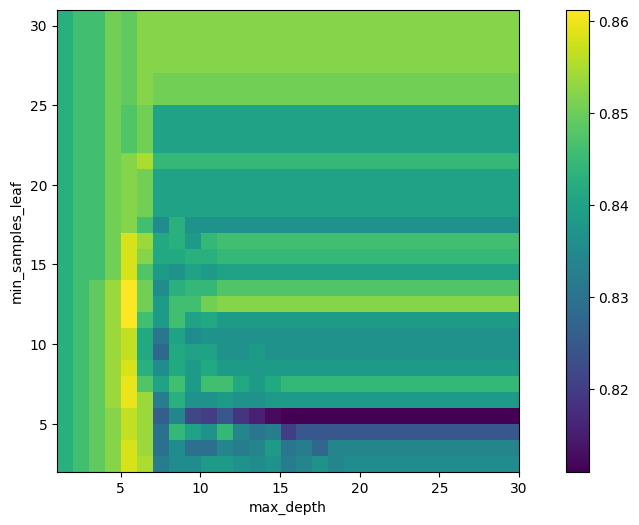

In [237]:
fig, ax = plt.subplots(figsize=(12, 6))

# notice that we are setting the extent and origin keywords
CS = ax.imshow(Z, extent=[1, 30, 2, 31], cmap='viridis', origin='lower')
ax.set(xlabel='max_depth', ylabel='min_samples_leaf')

fig.colorbar(CS);

***

### Sum up:

<img src="images/Chart.png" alt="Chart" width="800"/>

__[Guide To Hyperparameters Search For Deep Learning Models](https://blog.floydhub.com/guide-to-hyperparameters-search-for-deep-learning-models/)__

## Part E: New Methods

Bayesian Optimization meets HyperBand (BOHB)

HyperBand:


<img src="images/sh.gif" alt="BO vs. RS" width="600"/>

<img src="images/comparison_rs_bo.png" alt="BO vs. RS" width="600"/>

<img src="images/comparison-1.png" alt="BOHB" width="600"/>

__[BOHB: Robust and Efficient Hyperparameter Optimization at Scale](https://www.automl.org/blog_bohb/)__

## Part E2: Stealthy Hyperuniform Sampling

**New method (Lipiec et al., 2026):** Use *disordered stealthy hyperuniform* point distributions as the sampling set

- Combines benefits of **grid** (low density fluctuations, dense everywhere) and **random** search (good projective properties)
- Key insight: important hyperparameter directions are rarely known in advance and rarely axis-aligned

### Figure 1 — Lipiec et al. (2026)

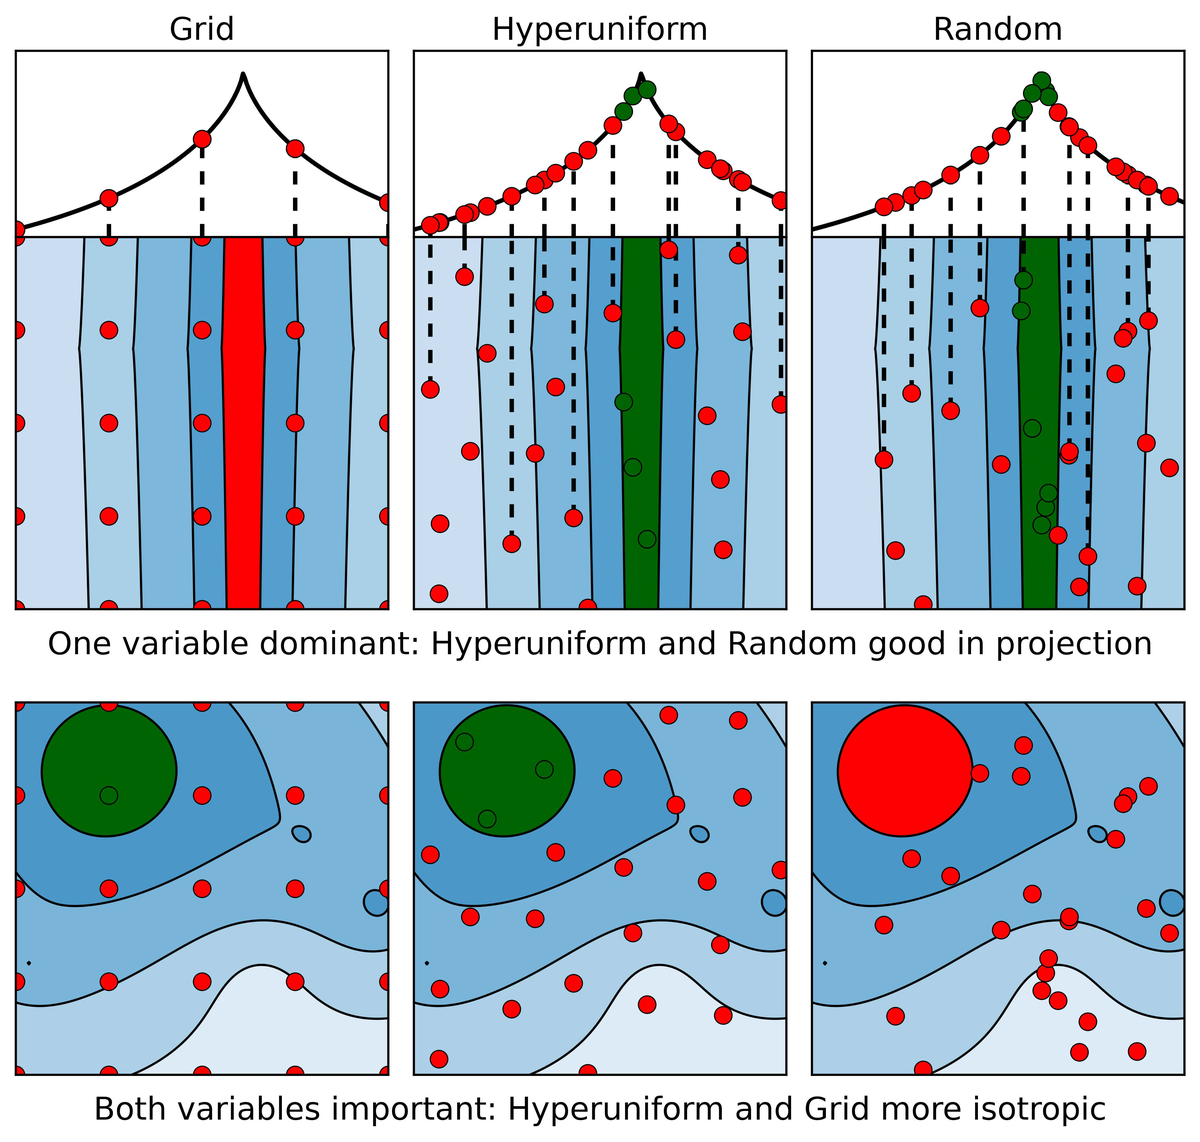

_Green = sampled near the maximum (success), Red = missed. **Top row:** one variable dominates — grid fails in projection; random and hyperuniform both succeed. **Bottom row:** both variables matter — random clusters; grid and hyperuniform are more isotropic. Hyperuniform **wins in both scenarios**._

### Why not just grid or random?

| Strategy | Dense everywhere? | Good projections? | Rotation-invariant? |
|----------|:-----------------:|:-----------------:|:-------------------:|
| Grid | ✅ | ❌ wastes samples | ❌ |
| Random | ❌ gaps & clusters | ✅ | ✅ |
| Sobol / Halton | ✅ | ✅ (axis-aligned) | ❌ |
| **Hyperuniform** | **✅** | **✅** | **✅** |

> *"...the variance of the number of points inside any observation window scales more slowly than its volume"*

### What is a stealthy hyperuniform point pattern?

Minimize the Fourier-space potential over a set of $N$ points $\{\mathbf{r}_j\}$:

$$\Phi = \sum_{0 < |\mathbf{k}| \leq K} S(\mathbf{k}), \qquad S(\mathbf{k}) = \frac{1}{N}\left|\sum_{j=1}^{N} e^{-i\mathbf{k}\cdot\mathbf{r}_j}\right|^2$$

- Suppressing $S(\mathbf{k})$ near zero eliminates long-wavelength density fluctuations
- The constraint fraction $\chi = M(K) / [d(N-1)]$ controls order: $\chi < 0.5$ keeps patterns **disordered**
- Empty regions (holes) are provably bounded in size

### Benchmark results (Lipiec et al., 2026)

Tested on multivariate synthetic functions, standard optimisation benchmarks (Rosenbrock, Schwefel, …), and a decision-tree HPO task — in 2–5 dimensions:

- Hyperuniform ($\chi = 0.4$) **outperforms random and grid** in most settings
- Unlike Sobol/Halton, **retains advantage after random rotation** of the loss landscape
- Rotation-invariance is the critical practical advantage when the important directions are unknown

__[Paper (IOP, 2026)](https://github.com/JonathanMelcher/Improved-Hyperparameter-Optimization)__ · __[Code: github.com/JonathanMelcher/Improved-Hyperparameter-Optimization](https://github.com/JonathanMelcher/Improved-Hyperparameter-Optimization)__

### Using hyperuniform sampling in practice

Install and generate a point set from the paper's repository:
```bash
git clone https://github.com/JonathanMelcher/Improved-Hyperparameter-Optimization
```

In [238]:
# Example: generate a stealthy hyperuniform point set and use it as the
# trial grid for any HPO task (replace the path with your clone location)
import sys, os
# sys.path.insert(0, 'Improved-Hyperparameter-Optimization/')  # uncomment after cloning

# --- Illustrative usage (pure-Python fallback using a pre-generated grid) ---
import numpy as np

# For a real run, load the hyperuniform grid from the repo:
# from hyperuniform import generate_hyperuniform_grid
# hu_points = generate_hyperuniform_grid(n_points=50, n_dims=2, chi=0.4)

# For illustration we use random points; swap in hu_points for the real thing
np.random.seed(42)
n_points, n_dims = 50, 2
hu_points = np.random.uniform(0, 1, size=(n_points, n_dims))  # placeholder

# Scale points to your hyperparameter ranges
max_depth_range   = (1, 100)
min_samples_range = (1, 50)

trial_max_depths       = (hu_points[:, 0] * (max_depth_range[1]   - max_depth_range[0])   + max_depth_range[0]).astype(int)
trial_min_samples_leaf = (hu_points[:, 1] * (min_samples_range[1] - min_samples_range[0]) + min_samples_range[0]).astype(int)

print('First 5 trial configurations (max_depth, min_samples_leaf):')
for md, ms in zip(trial_max_depths[:5], trial_min_samples_leaf[:5]):
    print(f'  max_depth={md:3d},  min_samples_leaf={ms:3d}')

First 5 trial configurations (max_depth, min_samples_leaf):
  max_depth= 38,  min_samples_leaf= 47
  max_depth= 73,  min_samples_leaf= 30
  max_depth= 16,  min_samples_leaf=  8
  max_depth=  6,  min_samples_leaf= 43
  max_depth= 60,  min_samples_leaf= 35


In [239]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Evaluate all hyperuniform trial points
results_hu = []
for md, ms in zip(trial_max_depths, trial_min_samples_leaf):
    clf = DecisionTreeClassifier(max_depth=md, min_samples_leaf=ms, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    results_hu.append({'max_depth': md, 'min_samples_leaf': ms, 'accuracy': acc})

best_hu = max(results_hu, key=lambda x: x['accuracy'])
print(f'Hyperuniform best:  max_depth={best_hu["max_depth"]}, '
      f'min_samples_leaf={best_hu["min_samples_leaf"]}, '
      f'accuracy={best_hu["accuracy"]:.4f}')

Hyperuniform best:  max_depth=5, min_samples_leaf=16, accuracy=0.8582


In [240]:
# ── Comparison: all five methods on the same dataset ──────────────────
print('Method                      Accuracy')
print('─' * 42)
print(f'Manual (babysitting)        {accuracy_manual:.4f}')
print(f'Grid Search                 {accuracy_GridSearch:.4f}')
print(f'Random Search               {accuracy_RandomSearch:.4f}')
print(f'Bayesian Optimization       {accuracy_BayesianOptimization:.4f}')
print(f'Hyperuniform Sampling       {best_hu["accuracy"]:.4f}  ← Lipiec et al. (2026)')


Method                      Accuracy
──────────────────────────────────────────
Manual (babysitting)        0.8201
Grid Search                 0.8430
Random Search               0.8460
Bayesian Optimization       0.8430
Hyperuniform Sampling       0.8582  ← Lipiec et al. (2026)


## Part F: New Software

__[Optuna](https://optuna.org/)__ is a HyperParameter Optimization framework.

In [241]:
import optuna
from optuna.samplers import TPESampler
from optuna.integration import LightGBMPruningCallback
from optuna.pruners import MedianPruner
import lightgbm as lgb

lgb_data_train = lgb.Dataset(X_train, label=y_train);

In [242]:
def objective(trial):

    boosting_types = ["gbdt", "rf", "dart"]
    boosting_type = trial.suggest_categorical("boosting_type", boosting_types)

    params = {
        "objective": "binary",
        "metric": 'auc',
        "boosting": boosting_type,
        "max_depth": 5,
        "max_depth": trial.suggest_int("max_depth", 2, 63),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-5, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 10.0, 30.0),
        "bagging_freq": 1, "bagging_fraction": 0.6,
        "verbosity": -1
    }

    N_iterations_max = 10_000
    early_stopping_rounds = 10

    if boosting_type == "dart":
        N_iterations_max = 100
        early_stopping_rounds = 0

    cv_res = lgb.cv(
        params,
        lgb_data_train,
        num_boost_round=N_iterations_max,
        seed=42,
        callbacks=[LightGBMPruningCallback(trial, "auc"),lgb.early_stopping(stopping_rounds=early_stopping_rounds),lgb.log_evaluation(period=0)],
    )

    num_boost_round = len(cv_res["valid auc-mean"])
    trial.set_user_attr("num_boost_round", num_boost_round)

    return cv_res["valid auc-mean"][-1]

In [243]:
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_warmup_steps=50),
)

study.optimize(objective, n_trials=100, show_progress_bar=True);

[I 2026-09-17 12:59:57,552] A new study created in memory with name: no-name-300fa47b-b412-4efc-8a5e-353d8fd8b5c6


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[27]	valid's auc: 0.923591 + 0.00625717
[I 2026-09-17 12:59:57,921] Trial 0 finished with value: 0.923591091502377 and parameters: {'boosting_type': 'rf', 'max_depth': 39, 'min_child_weight': 8.632008168602535e-05, 'scale_pos_weight': 13.119890406724053}. Best is trial 0 with value: 0.923591091502377.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[30]	valid's auc: 0.922688 + 0.00562831
[I 2026-09-17 12:59:58,191] Trial 1 finished with value: 0.9226879026588939 and parameters: {'boosting_type': 'rf', 'max_depth': 45, 'min_child_weight': 1.3289448722869181e-05, 'scale_pos_weight': 29.398197043239886}. Best is trial 0 with value: 0.923591091502377.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[75]	valid's auc: 0.931813 + 0.00638752
[I 2026-09-17 12:59:58,764] Trial 2 finished with value: 0.93181

C:\Users\cls8dx\AppData\Local\anaconda3\Lib\site-packages\lightgbm\callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[I 2026-09-17 12:59:59,608] Trial 3 finished with value: 0.9300085140349988 and parameters: {'boosting_type': 'dart', 'max_depth': 10, 'min_child_weight': 0.0005660670699258885, 'scale_pos_weight': 17.327236865873836}. Best is trial 2 with value: 0.9318133275583781.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[23]	valid's auc: 0.925103 + 0.00664956
[I 2026-09-17 12:59:59,851] Trial 4 finished with value: 0.925103266293118 and parameters: {'boosting_type': 'rf', 'max_depth': 33, 'min_child_weight': 0.035849855803404704, 'scale_pos_weight': 10.929008254399955}. Best is trial 2 with value: 0.9318133275583781.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:00,238] Trial 5 pruned. Trial was pruned at iteration 50.


...

[I 2026-09-17 13:00:24,651] Trial 58 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:25,138] Trial 59 pruned. Trial was pruned at iteration 57.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:25,685] Trial 60 pruned. Trial was pruned at iteration 60.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:26,095] Trial 61 pruned. Trial was pruned at iteration 51.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:26,518] Trial 62 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:26,968] Trial 63 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[76]	valid's auc: 0.932908 + 0.00669412
[I 2026-09-17 13:00:27,760] Trial 64 finished with value: 0.9329077283434337 and para

C:\Users\cls8dx\AppData\Local\anaconda3\Lib\site-packages\lightgbm\callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[I 2026-09-17 13:00:34,220] Trial 77 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:34,655] Trial 78 pruned. Trial was pruned at iteration 52.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:35,361] Trial 79 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:39,218] Trial 80 pruned. Trial was pruned at iteration 52.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:39,777] Trial 81 pruned. Trial was pruned at iteration 61.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:40,547] Trial 82 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[68]	valid's auc: 0.933736 + 0.00795931
[I 2026-09-17 13:00:41,587] Trial 83 finished with value: 0.9337361149229348 and para

C:\Users\cls8dx\AppData\Local\anaconda3\Lib\site-packages\lightgbm\callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[I 2026-09-17 13:00:45,690] Trial 90 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:46,627] Trial 91 pruned. Trial was pruned at iteration 58.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:47,307] Trial 92 pruned. Trial was pruned at iteration 58.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:47,826] Trial 93 pruned. Trial was pruned at iteration 58.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:48,367] Trial 94 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
[I 2026-09-17 13:00:48,990] Trial 95 pruned. Trial was pruned at iteration 50.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[62]	valid's auc: 0.93244 + 0.00561066
[I 2026-09-17 13:00:49,600] Trial 96 finished with value: 0.9324403583944525 and param

In [244]:
# To see all info at the best trial use:
study.best_trial

# To print metric values for all trials:
study.best_trial.intermediate_values

# To see distributions from which optuna samples parameters:
study.best_trial.distributions

{'boosting_type': CategoricalDistribution(choices=('gbdt', 'rf', 'dart')),
 'max_depth': IntDistribution(high=63, log=False, low=2, step=1),
 'min_child_weight': FloatDistribution(high=10.0, log=True, low=1e-05, step=None),
 'scale_pos_weight': FloatDistribution(high=30.0, log=False, low=10.0, step=None)}

In [245]:
# To simply get the optimized parameters:
study.best_trial.params

{'boosting_type': 'gbdt',
 'max_depth': 33,
 'min_child_weight': 0.26610017432546434,
 'scale_pos_weight': 11.089843426554513}

## Part G: What Else Is New? (2023–2026)

Beyond Bayesian Optimization, HyperBand, and hyperuniform sampling, the field has seen several important advances worth knowing about:

### 1. Population-Based Training (PBT) & PB2

**Core idea:** Run a *population* of models in parallel. Periodically copy weights from the top performers into the bottom performers, then *perturb* the hyperparameters of those copies and keep training.

- Optimizes **schedules** (learning rate, dropout) not just static values
- **PB2** (Parker-Holder et al., 2020) replaces random perturbation with a GP surrogate — continuous-time BO
- Natively parallel; scales to hundreds of workers

Available via `ray[tune]`: `PopulationBasedTraining` and `PB2` schedulers

__[PBT paper (Jaderberg et al., 2017)](https://arxiv.org/abs/1711.09846)__ · __[PB2 paper (Parker-Holder et al., 2020)](https://arxiv.org/abs/2002.02518)__

#### PBT — How It Works

```
Iteration 1:  [model_A λ₁]  [model_B λ₂]  [model_C λ₃]  [model_D λ₄]
                  ↓              ↓              ↓              ↓
              train...       train...       train...       train...

Exploit step: bottom 25% copy weights from top 25%
Explore step: perturb hyperparameters of copied models

Iteration 2:  [model_A λ₁]  [model_B λ₂]  [model_A' λ₁']  [model_B' λ₂']
```

Key advantage: hyperparameters *evolve during training*, not fixed upfront — ideal for learning-rate warmup/decay schedules.

### 2. SMAC3 & DEHB — Smarter Surrogates

**SMAC3** (Sequential Model-based Algorithm Configuration) uses a **Random Forest surrogate** instead of a Gaussian Process:

- Handles **mixed spaces** (categorical + integer + continuous) naturally
- More robust than GP at high dimensions and irregular domains
- Natively supports **multi-fidelity**: tries cheap approximations first (fewer epochs, smaller data)

**DEHB** (Differential Evolution + HyperBand, 2021) combines evolutionary search with the multi-fidelity bracket structure of HyperBand — often faster than BOHB on tabular HPO.

__[SMAC3 docs](https://smac3.readthedocs.io/)__ · __[DEHB paper (Awad et al., 2021)](https://arxiv.org/abs/2105.09821)__

#### SMAC3 — Random Forest Surrogate vs. GP

| Property | Gaussian Process (BO) | Random Forest (SMAC3) |
|----------|-----------------------|-----------------------|
| Scales to high dim | ❌ (O(n³) fit) | ✅ |
| Categorical params | ❌ needs encoding | ✅ native |
| Uncertainty estimate | Analytic | Variance of trees |
| Data efficiency | ✅ very sample-efficient | Good |
| Interpretability | ❌ | ✅ feature importances free |

For NLP/tabular AutoML pipelines with many categorical choices, SMAC3 is often the better pick.

### 3. Meta-Learning & Warm-Starting

**Problem:** Every HPO run starts cold — ignoring everything learned on similar tasks.

**Solution:** Transfer a surrogate model trained on *prior experiments*:

- **RGPE / FSBO / HyperFast** — learn a prior over loss surfaces from a meta-dataset
- **Optuna** supports `WarmStartCmaEsSampler` (reuse a previous study)
- **SMAC3** has an explicit meta-learning module

Practically: if you have tuned the same model architecture on 50 datasets before, warm-starting can cut the budget needed on a new dataset by 2–5×.

__[FSBO (Salinas et al., 2022)](https://arxiv.org/abs/2101.03051)__

#### Meta-Learning — Conceptually

```
Prior HPO runs (meta-dataset):
  Dataset 1 → best λ*₁,  loss curve₁
  Dataset 2 → best λ*₂,  loss curve₂
       ⋮
  Dataset K → best λ*_K, loss curve_K
           ↓  train meta-model
New task: initialize surrogate from meta-model
          → fewer evaluations to find λ* on new dataset
```

This is analogous to *few-shot learning* applied to optimization.

### 4. LLM-Guided HPO

**Core idea:** Prompt a large language model with:
1. Dataset metadata (size, task type, feature types)
2. Results of previous trials (λ → loss)
3. Ask it to propose the *next* configuration

**LLAMBO** (Liu et al., ICML 2024) frames HPO as **in-context learning**:
the LLM acts as a black-box surrogate + acquisition function.

- Works well for **low-budget** (≤50 trials) search on tabular data
- No training required — zero-shot
- Can leverage textual knowledge about algorithms (e.g., "high learning rates often overfit")

__[LLAMBO (ICML 2024)](https://arxiv.org/abs/2402.02547)__

#### LLAMBO — Prompting Strategy

```
System:  You are an expert at hyperparameter optimization.

User:    Task: binary classification, 5000 samples, 20 features.
         Model: LightGBM.
         Previous trials:
           {learning_rate: 0.1, max_depth: 6, n_estimators: 100}  → AUC 0.871
           {learning_rate: 0.01, max_depth: 4, n_estimators: 500} → AUC 0.884
           ...
         Suggest the next configuration to try.

LLM:     {learning_rate: 0.03, max_depth: 5, n_estimators: 300}
```

Still early-stage, but represents a paradigm shift — and a sign that the boundaries between HPO, AutoML, and foundation models are blurring.

### 5. Neural Architecture Search (NAS) as HPO

Architecture choices are just more hyperparameters:

- Number of layers, hidden sizes, skip connections, attention heads...
- **DARTS** (Liu et al., 2019): make architecture choices *differentiable* — jointly optimize weights and architecture with gradient descent
- **Once-for-All** (Cai et al., 2020): train one supernet, then slice out sub-networks for any target device without retraining
- **Hardware-aware NAS**: optimize *latency on target device* jointly with accuracy

The distinction between HPO and NAS has largely dissolved — modern AutoML frameworks treat both uniformly.

__[DARTS (ICLR 2019)](https://arxiv.org/abs/1806.09055)__ · __[Once-for-All (ICLR 2020)](https://arxiv.org/abs/1908.09791)__

#### DARTS — Differentiable Architecture Search

Replace discrete architecture choices with a **weighted mixture**:

$$\bar{o}^{(i,j)}(x) = \sum_{o \in \mathcal{O}} \frac{e^{\alpha_o^{(i,j)}}}{\sum_{o'} e^{\alpha_{o'}^{(i,j)}}} \, o(x)$$

- $\mathcal{O}$ = candidate operations (conv 3×3, conv 5×5, skip, zero, ...)
- $\alpha$ = architecture parameters, learned by gradient descent on the *validation* loss
- At the end, **discretize**: keep the operation with highest $\alpha$ on each edge

Reduces a combinatorial search over architectures to a continuous bilevel optimization.

# Happy Hyperparameter Optimization!

...and remember that this is useful for almost any problem you are trying to solve!

In [246]:
!jupyter nbconvert --to slides --SlidesExporter.reveal_scroll=True HyperparameterOptimization.ipynb

[NbConvertApp] Converting notebook HyperparameterOptimization.ipynb to slides
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 1125242 bytes to HyperparameterOptimization.slides.html
